# 05 — Volatilité stochastique : le modèle de Heston et sa calibration

**Question.** Un modèle à volatilité stochastique reproduit-il mieux les prix observés que Black-Scholes ?

Black-Scholes suppose $\sigma$ constant, alors que le notebook 04 montre une surface très structurée. Heston (1993) rend la variance aléatoire et corrélée au prix :

$$dS_t = (r-q) S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^{S}, \qquad dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^{v}, \qquad d\langle W^S, W^v\rangle_t = \rho\,dt$$

| Paramètre | Rôle | Effet sur la surface |
|---|---|---|
| $v_0$ | variance actuelle | niveau de l'IV courte |
| $\theta$ | variance de long terme | niveau de l'IV longue |
| $\kappa$ | vitesse de retour à la moyenne | vitesse de passage de $v_0$ à $\theta$ (pente de la structure par terme) |
| $\xi$ | volatilité de la variance (*vol-of-vol*) | courbure du smile (épaisseur des queues) |
| $\rho$ | corrélation spot / variance | **pente du skew** ($\rho<0$ : baisse du marché ⇒ hausse de la vol) |

**Condition de Feller** : $2\kappa\theta > \xi^2$ garantit que $v_t$ reste strictement positive. Elle est très souvent **violée** par les calibrations sur indices (il faut un gros $\xi$ pour produire le skew) : la variance touche alors zéro, ce qui n'invalide pas le modèle mais complique la simulation.

Pricing : formule semi-analytique par la fonction caractéristique (`src/heston_pricing.py`, formulation « little Heston trap » d'Albrecher et al., stable numériquement), ~1,5 ms par option.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotting import set_style, savefig, save_table, PALETTE

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 160)
%matplotlib inline
import json, time
from scipy.stats import norm, kurtosis, skew
from heston import simulate_heston_paths, satisfies_feller_condition
from heston_pricing import heston_call_price, heston_put_price
from implied_vol import implied_volatility
from calibration import (calibrate_heston, validate_calibration, plot_smiling_comparison,
                         plot_calibration_error_heatmap, plot_market_vs_heston_surfaces)
from pipeline import load_chain_with_iv, R_DEFAULT
from surface_tools import otm_slices, iv_at
from plotting import FIG_DIR, RES_DIR
r = R_DEFAULT

## 1. Pourquoi Heston génère un smile : effet de chaque paramètre

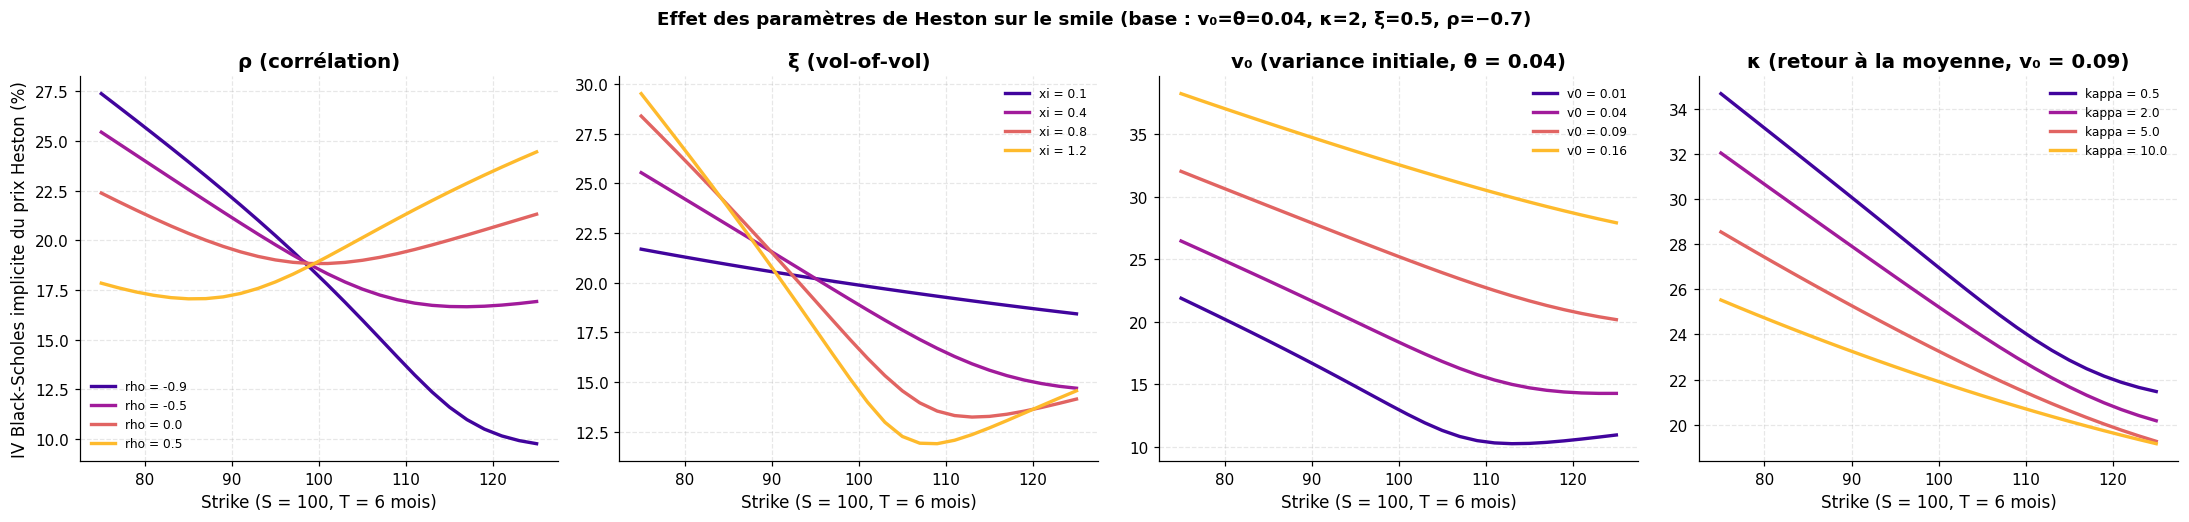

In [2]:
base = dict(v0=0.04, kappa=2.0, theta=0.04, xi=0.5, rho=-0.7)
Ks = np.linspace(75, 125, 26); T_ = 0.5

def heston_smile(p, T=T_):
    out = []
    for K in Ks:
        pr = heston_call_price(100, K, T, 0.0, **p) if K >= 100 else heston_put_price(100, K, T, 0.0, **p)
        out.append(implied_volatility(pr, 100, K, T, 0.0, "call" if K >= 100 else "put") * 100)
    return out

variations = {"rho": [-0.9, -0.5, 0.0, 0.5], "xi": [0.1, 0.4, 0.8, 1.2], "v0": [0.01, 0.04, 0.09, 0.16], "kappa": [0.5, 2.0, 5.0, 10.0]}
labels = {"rho": "ρ (corrélation)", "xi": "ξ (vol-of-vol)", "v0": "v₀ (variance initiale, θ = 0.04)", "kappa": "κ (retour à la moyenne, v₀ = 0.09)"}
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), sharex=True)
for ax, (par, vals) in zip(axes, variations.items()):
    cols = plt.cm.plasma(np.linspace(0.1, 0.85, len(vals)))
    for v, c in zip(vals, cols):
        p = dict(base); p[par] = v
        if par == "kappa": p["v0"] = 0.09
        ax.plot(Ks, heston_smile(p), lw=2.2, color=c, label=f"{par} = {v}")
    ax.set_title(labels[par]); ax.set_xlabel("Strike (S = 100, T = 6 mois)"); ax.legend(fontsize=8)
axes[0].set_ylabel("IV Black-Scholes implicite du prix Heston (%)")
fig.suptitle("Effet des paramètres de Heston sur le smile (base : v₀=θ=0.04, κ=2, ξ=0.5, ρ=−0.7)", fontweight="bold")
fig.tight_layout(); savefig(fig, "05_heston_parameter_effects.png"); plt.show()

- $\rho$ **pilote l'asymétrie** : $\rho=0$ donne un smile symétrique, $\rho<0$ un skew « action ». Intuition : si les baisses de marché s'accompagnent de hausses de vol, la queue gauche de la distribution s'épaissit, ce qui renchérit les puts OTM.
- $\xi$ **pilote la courbure** : plus la variance est volatile, plus les queues sont épaisses des deux côtés. Avec $\xi \to 0$, on retombe sur Black-Scholes (IV plate) — vérifié dans `tests/test_heston.py`.
- $v_0$ déplace le **niveau** ; $\kappa$ contrôle à quelle vitesse ce niveau converge vers $\sqrt\theta$ (effet sur la structure par terme).

## 2. Calibration sur la surface SPY du 1er août 2022

**Échantillon** : options OTM (plus liquides, pas de redondance call/put), 6 échéances mensuelles de 3 semaines à ~1 an, strikes multiples de 10 $ entre −25 % et +10 % de log-moneyness. **Fonction de perte** : erreur quadratique moyenne en IV (et non en prix, pour ne pas surpondérer les options chères ITM/longues). **Optimiseur** : L-BFGS-B sous contraintes de bornes, **multi-start** à trois départs (guidé par le marché : $v_0 = \sigma^2_{ATM,1M}$, $\theta = \sigma^2_{ATM,1A}$ ; celui du script d'origine ; un départ « stress » à $\kappa$ et $\xi$ élevés), avec **repli sur Powell** (sans gradient) si L-BFGS-B s'arrête anormalement ; on retient la perte minimale.

In [3]:
MONTHLY_TARGET_DAYS = [21, 45, 80, 140, 230, 320]
BOUNDS = [(0.001, 1.0), (0.01, 10.0), (0.001, 1.0), (0.01, 5.0), (-0.99, 0.99)]

def calibration_sample(df, strike_step=10, lm_range=(-0.25, 0.10)):
    d = df[(df.iv_status == "success") & df.is_otm & df.log_moneyness.between(*lm_range)].copy()
    exps = d.groupby("expiration")["T"].first()
    third_fridays = exps[[e.weekday() == 4 and 15 <= e.day <= 21 for e in exps.index]]
    chosen = sorted({third_fridays.index[np.argmin(np.abs(third_fridays.values - t / 365))] for t in MONTHLY_TARGET_DAYS})
    return d[d.expiration.isin(chosen) & (d.strike % strike_step == 0)], d[d.expiration.isin(chosen)]

X0_ORIGIN = [0.04, 2.0, 0.04, 0.3, -0.7]   # point de départ du script calibration.py d'origine

def run_calibration(date, verbose=True):
    """Multi-start (3 départs) ; repli Powell si L-BFGS-B s'arrête anormalement ; on garde la perte minimale."""
    df, _, _ = load_chain_with_iv(date)
    calib, full = calibration_sample(df)
    sl = otm_slices(df)
    v0_mkt, th_mkt = iv_at(sl, 0.0, 30/365)**2, iv_at(sl, 0.0, 1.0)**2
    starts = {"Guidé par le marché": [v0_mkt, 2.0, th_mkt, 0.5, -0.7],
              "Script d'origine": X0_ORIGIN,
              "Stress (κ, ξ élevés)": [v0_mkt, 5.0, th_mkt, 2.0, -0.6]}
    runs = {}
    for lab, x0 in starts.items():
        t0 = time.perf_counter()
        rr = calibrate_heston(calib, x0, BOUNDS, r=r, q="q_implied", iv_col="implied_vol")
        rr["time"], rr["x0"] = time.perf_counter() - t0, x0
        runs[lab] = rr
    best_lab = min(runs, key=lambda k: runs[k]["loss"])
    res = runs[best_lab]; res["all_runs"] = runs; res["best_start"] = best_lab
    if verbose:
        print(f"{date} : {len(calib)} options, {calib.expiration.nunique()} échéances | "
              + " | ".join(f"{k} : {100*np.sqrt(v['loss']):.2f} pts ({v['method']}, {v['time']:.0f} s)" for k, v in runs.items())
              + f"  -> retenu : {best_lab}")
    return res, calib, full, df

REF_DATE = "2022-08-01"
res, calib, full, df_ref = run_calibration(REF_DATE)
robust = pd.DataFrame([dict(zip(["v0", "kappa", "theta", "xi", "rho"], rr["params"]), **{"Départ": lab, "RMSE (pts)": 100*np.sqrt(rr["loss"]), "Méthode": rr["method"], "Évaluations": rr["n_evaluations"]})
                       for lab, rr in res["all_runs"].items()]).set_index("Départ")
save_table(robust.reset_index(), "05_calibration_robustness")
display(robust)
v0, kappa, theta, xi, rho = res["params"]
feller = satisfies_feller_condition(kappa, theta, xi)
params_tab = pd.DataFrame({
    "Paramètre": ["v0", "kappa", "theta", "xi", "rho"],
    "Point de départ retenu": res["x0"], "Calibré": res["params"],
    "Interprétation": [f"vol instantanée √v0 = {np.sqrt(v0):.1%}", f"demi-vie du choc de variance ≈ {np.log(2)/kappa*12:.1f} mois",
                       f"vol de long terme √θ = {np.sqrt(theta):.1%}", "vol-of-vol", "corrélation spot-variance"]})
print(f"Condition de Feller 2κθ > ξ² : {2*kappa*theta:.3f} > {xi**2:.3f} -> {'respectée' if feller else 'VIOLÉE'}")
save_table(params_tab, "05_heston_params_ref_date")
json.dump({"date": REF_DATE, "v0": v0, "kappa": kappa, "theta": theta, "xi": xi, "rho": rho,
           "rmse_iv_pts": 100*np.sqrt(res["loss"]), "feller": bool(feller)}, open(RES_DIR / "heston_params.json", "w"), indent=2)
params_tab

2022-08-01 : 84 options, 6 échéances | Guidé par le marché : 0.89 pts (L-BFGS-B, 384 s) | Script d'origine : 0.89 pts (L-BFGS-B, 328 s) | Stress (κ, ξ élevés) : 0.97 pts (L-BFGS-B, 150 s)  -> retenu : Guidé par le marché


,v0,kappa,theta,xi,rho,RMSE (pts),Méthode,Évaluations
Départ,,,,,,,,
Guidé par le marché,0.0423,9.3649,0.0720,2.1243,-0.5962,0.8877,L-BFGS-B,456
Script d'origine,0.0423,9.3087,0.0721,2.1313,-0.5938,0.8878,L-BFGS-B,390
"Stress (κ, ξ élevés)",0.0456,5.0623,0.0819,1.7799,-0.5800,0.9740,L-BFGS-B,168


Condition de Feller 2κθ > ξ² : 1.348 > 4.512 -> VIOLÉE


,Paramètre,Point de départ retenu,Calibré,Interprétation
0,v0,0.0403,0.0423,vol instantanée √v0 = 20.6%
1,kappa,2.0000,9.3649,demi-vie du choc de variance ≈ 0.9 mois
2,theta,0.0505,0.0720,vol de long terme √θ = 26.8%
3,xi,0.5000,2.1243,vol-of-vol
4,rho,-0.7000,-0.5962,corrélation spot-variance


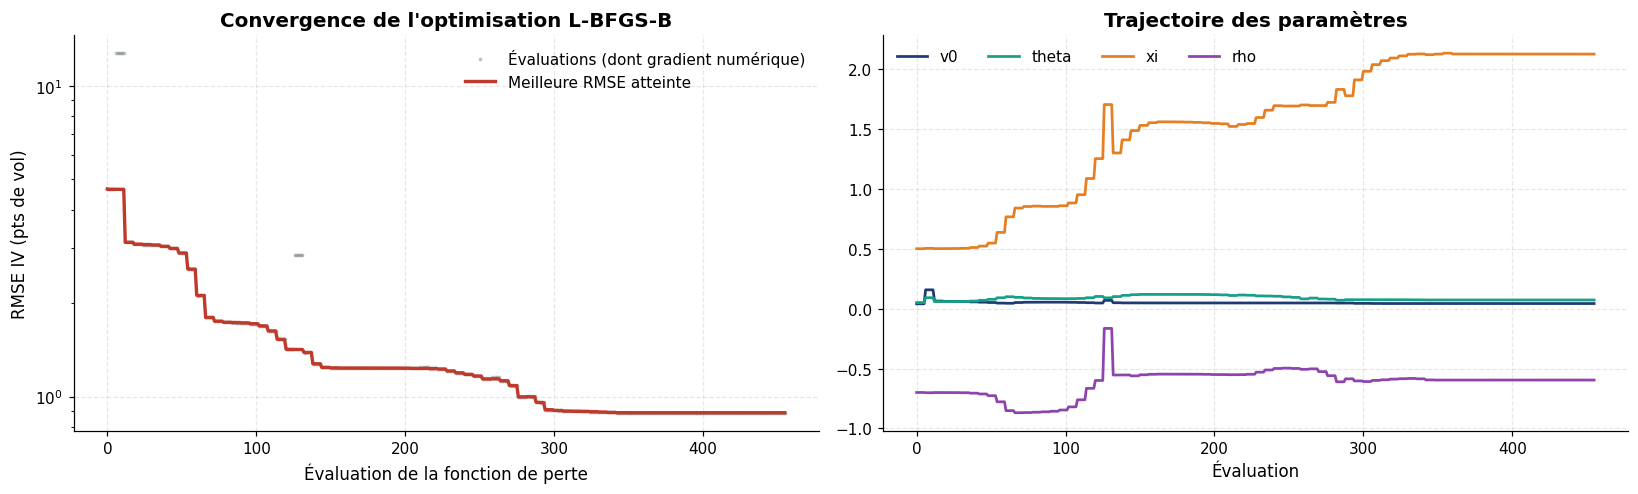

In [4]:
h = res["history"].copy()
h["rmse_pts"] = 100 * np.sqrt(h.loss.clip(upper=1))
h = h[h.loss < 1]
best = h.rmse_pts.cummin()
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
axes[0].plot(h.rmse_pts.values, ".", ms=3, alpha=0.4, color=PALETTE["grey"], label="Évaluations (dont gradient numérique)")
axes[0].plot(best.values, color=PALETTE["crimson"], lw=2.2, label="Meilleure RMSE atteinte")
axes[0].set_xlabel("Évaluation de la fonction de perte"); axes[0].set_ylabel("RMSE IV (pts de vol)"); axes[0].set_yscale("log")
axes[0].set_title("Convergence de l'optimisation L-BFGS-B"); axes[0].legend()
for p_, c in zip(["v0", "theta", "xi", "rho"], [PALETTE["navy"], PALETTE["teal"], PALETTE["orange"], PALETTE["purple"]]):
    axes[1].plot(h[p_].values, color=c, lw=1.8, label=p_)
axes[1].set_xlabel("Évaluation"); axes[1].set_title("Trajectoire des paramètres"); axes[1].legend(ncol=4)
fig.tight_layout(); savefig(fig, "05_calibration_convergence.png"); plt.show()

**Lecture.** Le départ guidé par le marché et celui du script d'origine convergent vers **la même solution** (RMSE 0,888 pt). Le départ « stress » s'arrête dans la même vallée, un peu plus haut (0,97 pt), avec un $\kappa$ plus faible compensé par un $\theta$ plus élevé. $\kappa$, $\theta$ et $\xi$ se compensent partiellement (vallée plate) : c'est le problème classique d'**identifiabilité** de Heston. $\rho$ et $v_0$, eux, sont robustes.

**Leçon numérique importante.** Avec la version initiale du pricer (intégrale de Fourier tronquée à $u \le 100$), ces mêmes départs donnaient deux solutions très différentes (RMSE 0,82 et 1,39 pt). Le bruit d'intégration aux maturités courtes créait de **faux minima locaux**. Une calibration n'est jamais meilleure que la précision du pricer qu'elle appelle (voir `docs/MODIFICATIONS.md`).

## 3. Qualité de l'ajustement (fonction `validate_calibration` du projet)

Échantillon de calibration puis validation **hors échantillon** sur tous les strikes OTM des mêmes échéances (y compris ceux non utilisés dans la calibration).

In [5]:
df_val = validate_calibration(calib, res["params"], r=r, q="q_implied")

RAPPORT D'ERREUR GLOBALE (en points de vol)
• RMSE de l'IV         : 0.8877 pts
• MAE de l'IV          : 0.6986 pts
• Erreur maximale abs. : 3.1749 pts

10.2 ERREUR PAR MATURITÉ
maturity_bucket  Nombre_de_points  RMSE_IV  MAE_IV
    Court terme                28   1.2335  1.0129
    Moyen terme                28   0.5002  0.4416
     Long terme                28   0.7697  0.6413


10.3 ERREUR PAR LOG-MONEYNESS (Skew et Ailes)
         moneyness_bucket  Nombre_de_points  RMSE_IV  MAE_IV
          Autour de l'ATM                24   0.7207  0.6513
   Strikes bas (Puts OTM)                48   0.9703  0.7340
Strikes hauts (Calls OTM)                12   0.8436  0.6513


In [6]:
df_oos = validate_calibration(full, res["params"], r=r, q="q_implied", verbose=False)
print(f"Hors échantillon ({len(df_oos)} options) : RMSE = {np.sqrt(df_oos.sq_iv_error_pts.mean()):.2f} pts | "
      f"MAE = {df_oos.abs_iv_error_pts.mean():.2f} pts")

Hors échantillon (652 options) : RMSE = 0.88 pts | MAE = 0.69 pts


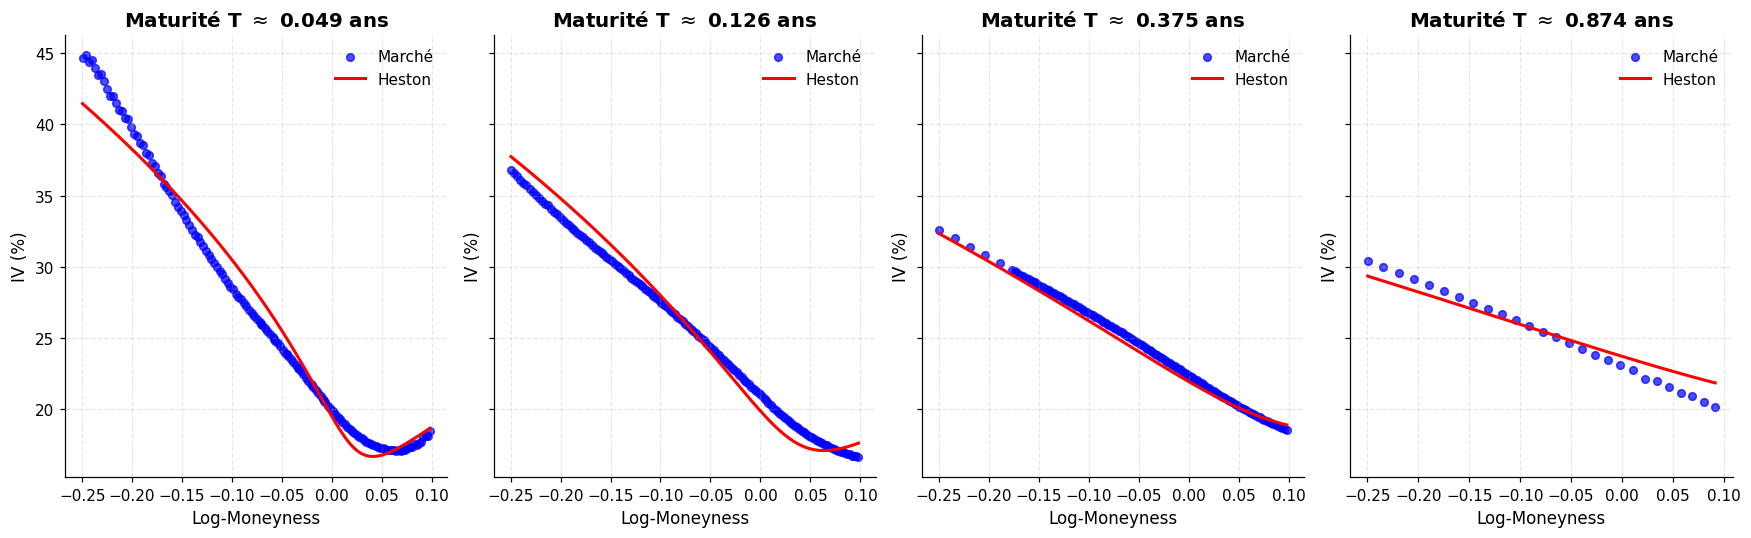

In [7]:
plot_smiling_comparison(df_oos, n_maturities=4, save_path=FIG_DIR / "05_heston_vs_market_smiles.png")

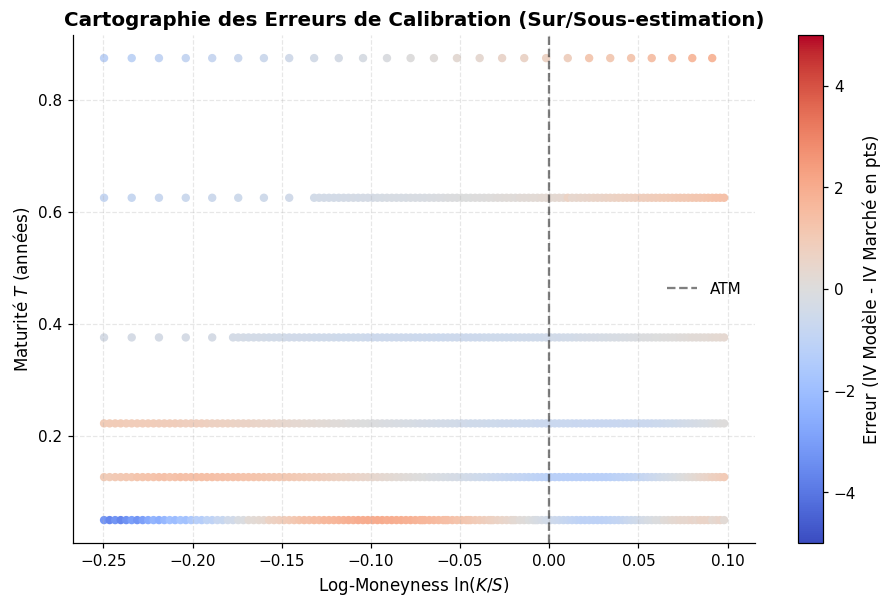

In [8]:
plot_calibration_error_heatmap(df_oos, save_path=FIG_DIR / "05_calibration_error_map.png")

## 4. Black-Scholes vs Heston

Comparaison à armes égales sur les mêmes options : Black-Scholes avec **une seule vol** pour toute la surface (le modèle au sens strict), Black-Scholes avec **une vol ATM par maturité** (ce qu'un trader ferait « à la main »), et Heston (5 paramètres pour toute la surface).

In [9]:
sl = otm_slices(df_ref)
d = df_oos.copy()
d["spot"] = d.strike / np.exp(d.log_moneyness)
d["iv_bs_flat"] = d.iv_market.mean()
d["iv_bs_atm"] = [iv_at(sl, 0.0, T) * 100 for T in d["T"]]
def rmse(x): return np.sqrt(np.mean(np.square(x)))
comp = pd.DataFrame({
    "Modèle": ["Black-Scholes (1 vol pour toute la surface)", "Black-Scholes (vol ATM par maturité)", "Heston (5 paramètres)"],
    "Nb paramètres": [1, d["T"].nunique(), 5],
    "RMSE (pts)": [rmse(d.iv_bs_flat - d.iv_market), rmse(d.iv_bs_atm - d.iv_market), rmse(d.iv_model - d.iv_market)],
    "MAE (pts)": [np.mean(np.abs(d.iv_bs_flat - d.iv_market)), np.mean(np.abs(d.iv_bs_atm - d.iv_market)), np.mean(np.abs(d.iv_model - d.iv_market))],
    "Erreur max (pts)": [np.max(np.abs(d.iv_bs_flat - d.iv_market)), np.max(np.abs(d.iv_bs_atm - d.iv_market)), np.max(np.abs(d.iv_model - d.iv_market))],
})
save_table(comp, "05_bs_vs_heston_global", floatfmt=".2f"); comp

,Modèle,Nb paramètres,RMSE (pts),MAE (pts),Erreur max (pts)
0,Black-Scholes (1 vol pour toute la surface),1,5.8131,4.6439,19.7530
1,Black-Scholes (vol ATM par maturité),6,7.1640,5.1824,25.0653
2,Heston (5 paramètres),5,0.8826,0.6893,3.6144


In [10]:
# Tableau par strike pour l'échéance ~3 mois (format de la consigne)
T3 = sorted(d["T"].unique(), key=lambda t: abs(t - 0.25))[0]
g = d[d["T"] == T3].copy(); g["spot"] = g.strike / np.exp(g.log_moneyness)
rows = []
for m in [0.85, 0.90, 0.95, 1.00, 1.05, 1.10]:
    K = m * g.spot.iloc[0]
    row = g.iloc[(g.strike - K).abs().argmin()]
    rows.append({"Strike (% spot)": f"{row.strike / row.spot:.1%}", "Strike": row.strike, "IV marché": row.iv_market,
                 "IV BS (ATM)": row.iv_bs_atm, "IV Heston": row.iv_model,
                 "Erreur BS (pts)": row.iv_bs_atm - row.iv_market, "Erreur Heston (pts)": row.iv_model - row.iv_market})
tab3 = pd.DataFrame(rows)
print(f"Échéance {g.expiration.iloc[0].date()} (T = {T3:.3f} an)")
save_table(tab3, "05_bs_vs_heston_by_strike", floatfmt=".2f"); tab3

Échéance 2022-10-21 (T = 0.222 an)


,Strike (% spot),Strike,IV marché,IV BS (ATM),IV Heston,Erreur BS (pts),Erreur Heston (pts)
0,85.0%,349.0000,29.8263,21.3477,30.3433,-8.4786,0.5170
1,90.1%,370.0000,27.0428,21.3477,27.0372,-5.6952,-0.0056
2,95.0%,390.0000,24.2835,21.3477,23.8768,-2.9359,-0.4067
3,100.1%,411.0000,21.4005,21.3477,20.7400,-0.0528,-0.6605
4,104.9%,431.0000,19.1906,21.3477,18.5100,2.1571,-0.6806
5,110.1%,452.0000,17.7338,21.3477,17.7390,3.6139,0.0051


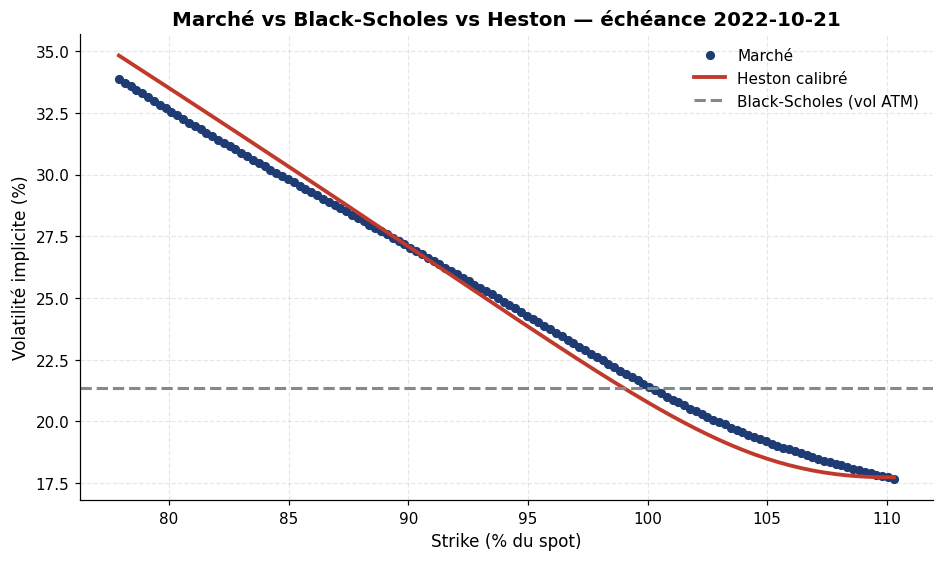

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.5))
g = g.sort_values("log_moneyness")
ax.plot(g.strike / g.spot * 100, g.iv_market, "o", color=PALETTE["navy"], ms=5, label="Marché")
ax.plot(g.strike / g.spot * 100, g.iv_model, "-", color=PALETTE["crimson"], lw=2.5, label="Heston calibré")
ax.axhline(g.iv_bs_atm.iloc[0], color=PALETTE["grey"], ls="--", lw=2, label="Black-Scholes (vol ATM)")
ax.set_xlabel("Strike (% du spot)"); ax.set_ylabel("Volatilité implicite (%)")
ax.set_title(f"Marché vs Black-Scholes vs Heston — échéance {g.expiration.iloc[0].date()}"); ax.legend()
savefig(fig, "05_bs_vs_heston_smile.png"); plt.show()

## 5. Dynamique simulée avec les paramètres calibrés

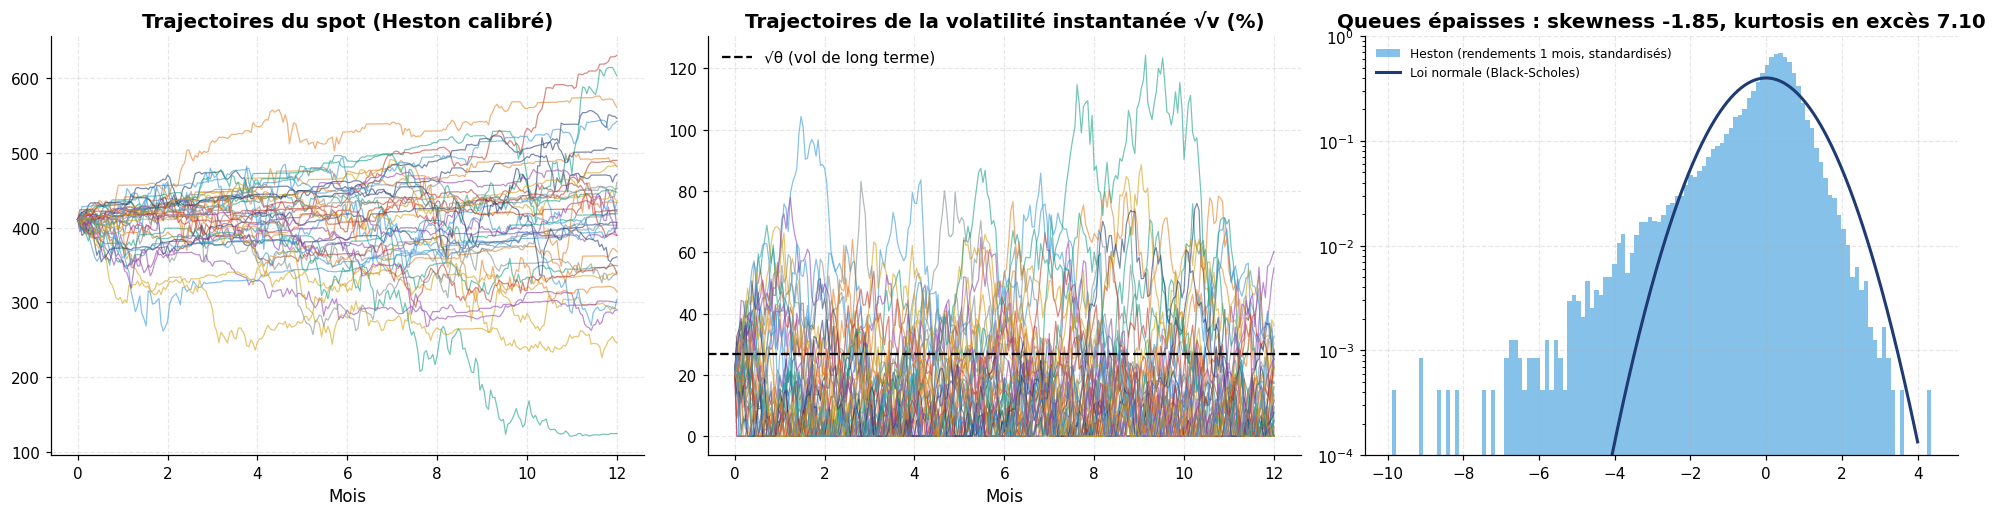

Part des pas où la variance simulée est tronquée à 0 : 21.28 % (Feller violée)


In [12]:
S_sim, v_sim = simulate_heston_paths(410.72, v0, r, kappa, theta, xi, rho, 1.0, 252, 20_000, seed=0)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
t = np.linspace(0, 12, 253)
for j in range(40):
    axes[0].plot(t, S_sim[:, j], lw=0.8, alpha=0.6)
    axes[1].plot(t, np.sqrt(np.maximum(v_sim[:, j], 0)) * 100, lw=0.8, alpha=0.6)
axes[0].set_title("Trajectoires du spot (Heston calibré)"); axes[0].set_xlabel("Mois")
axes[1].axhline(np.sqrt(theta) * 100, color="k", ls="--", label="√θ (vol de long terme)"); axes[1].legend()
axes[1].set_title("Trajectoires de la volatilité instantanée √v (%)"); axes[1].set_xlabel("Mois")
lr = np.log(S_sim[21] / S_sim[0])
lr_std = (lr - lr.mean()) / lr.std(); xs = np.linspace(-5, 4, 300)
axes[2].hist(lr_std, bins=120, density=True, color=PALETTE["sky"], alpha=0.6, label="Heston (rendements 1 mois, standardisés)")
axes[2].plot(xs, norm.pdf(xs), color=PALETTE["navy"], lw=2, label="Loi normale (Black-Scholes)")
axes[2].set_yscale("log"); axes[2].set_ylim(1e-4, 1); axes[2].legend(fontsize=8)
axes[2].set_title(f"Queues épaisses : skewness {skew(lr):.2f}, kurtosis en excès {kurtosis(lr):.2f}")
fig.tight_layout(); savefig(fig, "05_heston_simulation.png"); plt.show()
print(f"Part des pas où la variance simulée est tronquée à 0 : {100*np.mean(v_sim <= 0):.2f} % (Feller violée)")

## 6. Les paramètres changent-ils avec le régime de marché ?

La calibration sur les 4 dates de régime du notebook 04 (calme, stress, rebond, sell-off) représente 12 calibrations complètes (~25 min). Elle est isolée dans `scripts/calibrate_regimes.py`, qui produit `results/05_heston_params_by_regime.md` et `figures/05_heston_params_by_regime.png` avec exactement les mêmes fonctions que ce notebook.

## Conclusions

1. **Heston bat nettement Black-Scholes** : avec 5 paramètres pour toute la surface, la RMSE **hors échantillon** (652 options) tombe à **0,88 pt de vol**, contre 5,81 pts pour Black-Scholes à vol unique (÷6,6). Un Black-Scholes avec une vol ATM par maturité fait même **pire** (7,16 pts) : l'ATM est au creux du skew, donc tous les puts OTM sont sous-évalués. Heston capture le **skew** via $\rho$ et la **courbure** via $\xi$ : sur l'échéance à 3 mois, l'erreur Heston reste sous 0,7 pt de 85 % à 110 % du spot, alors que Black-Scholes se trompe de 8,5 pts à 85 %.
2. **Paramètres économiquement cohérents** (01/08/2022) : $\sqrt{v_0}$ = 20,6 % (proche de la vol ATM courte), $\sqrt\theta$ = 26,8 % (vol de long terme), $\kappa$ = 9,4 (retour rapide, demi-vie de ~1 mois), $\xi$ = 2,12 (queues épaisses), $\rho$ = −0,60 (effet de levier).
3. **Condition de Feller violée** (2κθ = 1,35 < ξ² = 4,51) : pour reproduire un skew d'indice, il faut une forte vol-of-vol. La variance simulée est tronquée à 0 sur **21 %** des pas, ce qui impose un schéma robuste (troncature ici, schéma QE d'Andersen en production).
4. **La qualité numérique conditionne la calibration** : la troncature fixe de l'intégrale de Fourier créait de faux minima locaux, et une perte discontinue (options non inversibles retirées de la moyenne) bloquait L-BFGS-B. D'où la borne d'intégration adaptative, le multi-start et le repli sans gradient.
5. **Limites** : l'erreur est concentrée sur les **maturités courtes** (RMSE 1,23 pt contre 0,50 pt à moyen terme). Heston est un modèle de diffusion : il ne peut pas générer le skew très pentu des options à quelques semaines (skew mesuré ∝ $T^{-0.3}$). Extensions naturelles : sauts (Bates), volatilité rugueuse, volatilité locale-stochastique (SLV).
6. **Recalibration et risque de modèle** : un jeu de paramètres calibré à une date ne décrit pas la dynamique future (voir `scripts/calibrate_regimes.py`). Les desks recalibrent quotidiennement, ce qui crée un risque de modèle pour la couverture (notebook 06, section 6).
